# Red Wine Quality — What Makes a Wine "Good"?

**Business question:** Which physicochemical properties distinguish a high-quality ("good") red wine from the rest, and how accurately can we predict it — practically enough to be useful for a winery's quality control?

Dataset: [Red Wine Quality (Cortez et al., 2009) — Kaggle/UCI](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009) — 1,599 Portuguese "Vinho Verde" red wines, 11 physicochemical inputs (acidity, sugar, chlorides, sulfur dioxide, density, pH, sulphates, alcohol) and a 0–10 expert quality score.

Following the dataset's own suggested approach: binarize quality at a cutoff (≥7 = "good"), drop the raw 10-point score to prevent leakage, and evaluate classifiers by ROC/AUC rather than accuracy alone, since the classes are imbalanced.

The CSV is included directly in `data/`, so this notebook runs as-is — no download needed.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

df = pd.read_csv('data/winequality-red.csv')
print('Missing values:', df.isna().sum().sum())
print('Exact duplicate rows:', df.duplicated().sum(), f"({df.duplicated().mean():.1%})")
df.shape

Missing values: 0
Exact duplicate rows: 240 (15.0%)


(1599, 12)

**Data quality note:** 240 of 1,599 rows (15%) are exact duplicates — a known property of this dataset (many wines share identical rounded lab measurements). We keep the full data for exploratory analysis below, but de-duplicate before modeling so the same wine can't appear in both the train and test split.

## 1. Quality score distribution

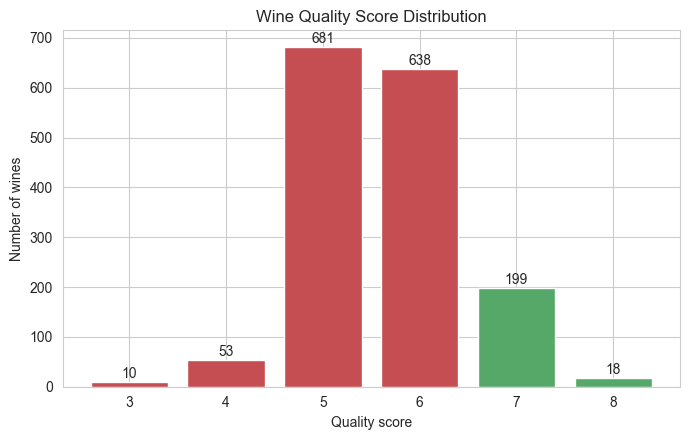

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

'Good' (quality >= 7) share: 13.6%


In [2]:
plt.figure(figsize=(7, 4.5))
counts = df['quality'].value_counts().sort_index()
colors = ['#C44E52' if q < 7 else '#55A868' for q in counts.index]
plt.bar(counts.index.astype(str), counts.values, color=colors)
plt.title('Wine Quality Score Distribution')
plt.xlabel('Quality score')
plt.ylabel('Number of wines')
for i, v in enumerate(counts.values):
    plt.text(i, v + 8, str(v), ha='center')
plt.tight_layout()
plt.savefig('images/01_quality_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(counts)
print(f"\n'Good' (quality >= 7) share: {(df['quality'] >= 7).mean():.1%}")

Quality is heavily concentrated at 5 and 6 (normal wines); "good" wines (≥7, shown in green) are only **13.6%** of the data, and there are no wines rated below 3 or above 8. This confirms the dataset's own framing — a rare-class problem, so accuracy alone is a misleading metric and ROC/AUC (or precision/recall) is the right lens.

## 2. Which features actually correlate with quality?

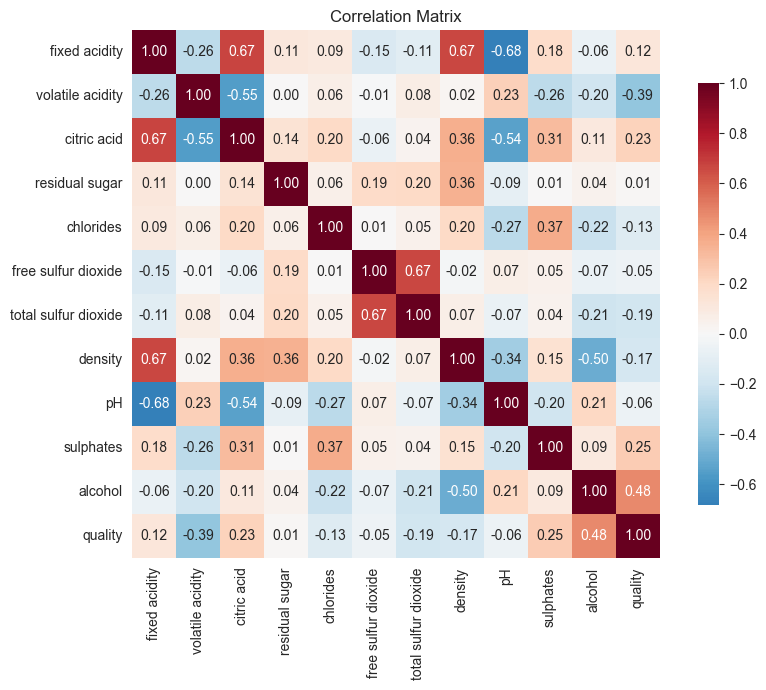

alcohol                 0.476166
volatile acidity       -0.390558
sulphates               0.251397
citric acid             0.226373
total sulfur dioxide   -0.185100
density                -0.174919
chlorides              -0.128907
fixed acidity           0.124052
pH                     -0.057731
free sulfur dioxide    -0.050656
residual sugar          0.013732
Name: quality, dtype: float64

In [3]:
plt.figure(figsize=(9, 7))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('images/02_correlation_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

corr['quality'].drop('quality').sort_values(key=abs, ascending=False)

**Alcohol (+0.48) and volatile acidity (-0.39) are by far the strongest linear correlates of quality**, followed by sulphates (+0.25) and citric acid (+0.23). Volatile acidity is essentially the acetic-acid ("vinegar") off-flavor — its negative relationship matches basic wine chemistry.

## 3. How do the top features differ between good and other wines?

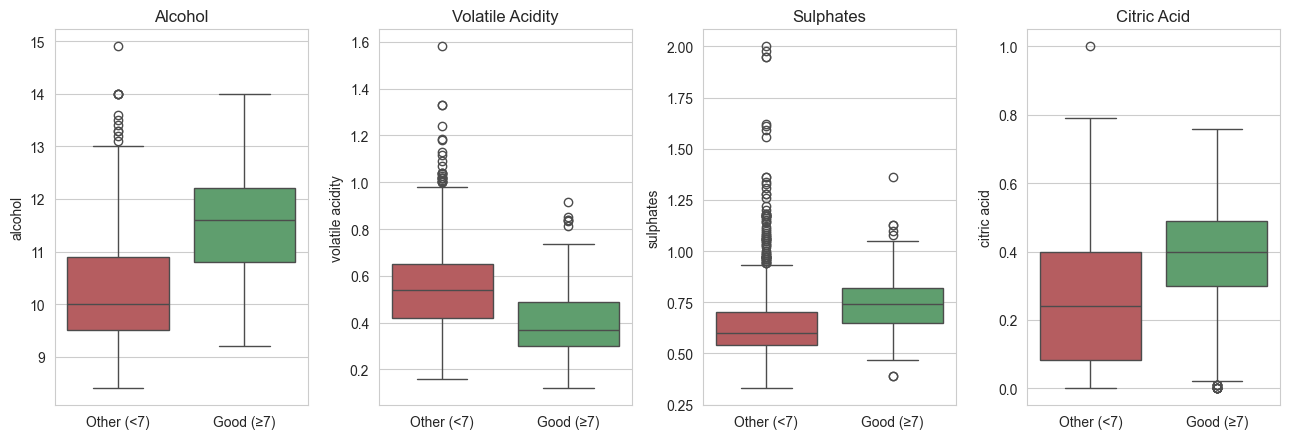

,alcohol,volatile acidity,sulphates,citric acid
Category,,,,
Good (≥7),11.518,0.406,0.743,0.376
Other (<7),10.251,0.547,0.645,0.254


In [4]:
df['Category'] = np.where(df['quality'] >= 7, 'Good (≥7)', 'Other (<7)')
top_features = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid']

fig, axes = plt.subplots(1, 4, figsize=(13, 4.5))
for ax, feat in zip(axes, top_features):
    sns.boxplot(data=df, x='Category', y=feat, hue='Category', palette=['#C44E52', '#55A868'], legend=False, ax=ax)
    ax.set_title(feat.title())
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig('images/03_feature_distributions_by_quality.png', bbox_inches='tight', dpi=150)
plt.show()

df.groupby('Category')[top_features].mean().round(3)

Good wines average noticeably **higher alcohol, sulphates, and citric acid**, and **lower volatile acidity**, than the rest — visually confirming the correlation results with separation that's real but far from perfect (the boxes overlap substantially), which is why we need a model rather than a single-feature rule.

## 4. Framing it as classification

Per the dataset's own suggested approach: create a binary `good` target (quality ≥ 7 → 1, else 0), then **drop the raw `quality` column from the features** — leaving it in would leak the answer directly into the model. We also de-duplicate rows first so identical wines can't leak across the train/test split, and use a stratified 75/25 split to preserve the ~14% "good" rate in both sets.

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

model_df = df.drop(columns=['Category']).drop_duplicates().reset_index(drop=True)
print(f'Unique rows for modeling: {len(model_df)} (was {len(df)})')

model_df['good'] = (model_df['quality'] >= 7).astype(int)
X = model_df.drop(columns=['quality', 'good'])
y = model_df['good']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)
baseline_acc = y_test.value_counts(normalize=True).max()
print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Baseline ("always predict not-good") accuracy: {baseline_acc:.1%}')

Unique rows for modeling: 1359 (was 1599)
Train: (1019, 11), Test: (340, 11)
Baseline ("always predict not-good") accuracy: 86.5%


## 5. Model comparison: Logistic Regression vs. tuned Decision Tree vs. Random Forest

The dataset's own tip suggests a decision tree tuned for ROC/AUC should reach ~0.88 AUC without feature engineering or a random forest. We test that directly, plus a scaled logistic regression and a random forest, all compared on the same held-out test set.

In [6]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

results = {}
roc_data = {}

# Logistic Regression
logreg = LogisticRegression(max_iter=1000, class_weight='balanced')
logreg.fit(X_train_s, y_train)
proba = logreg.predict_proba(X_test_s)[:, 1]
results['Logistic Regression'] = {'AUC': roc_auc_score(y_test, proba), 'Accuracy': accuracy_score(y_test, logreg.predict(X_test_s))}
roc_data['Logistic Regression'] = roc_curve(y_test, proba)

# Decision Tree, hyperparameter-tuned via grid search on ROC AUC (5-fold CV)
param_grid = {'max_depth': [2, 3, 4, 5, 6, 8, None], 'min_samples_leaf': [1, 2, 5, 10, 20]}
dt_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid, scoring='roc_auc', cv=StratifiedKFold(5, shuffle=True, random_state=42)
)
dt_search.fit(X_train, y_train)
best_dt = dt_search.best_estimator_
proba_dt = best_dt.predict_proba(X_test)[:, 1]
results['Decision Tree (tuned)'] = {'AUC': roc_auc_score(y_test, proba_dt), 'Accuracy': accuracy_score(y_test, best_dt.predict(X_test))}
roc_data['Decision Tree (tuned)'] = roc_curve(y_test, proba_dt)
print('Best decision tree params:', dt_search.best_params_)

# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
proba_rf = rf.predict_proba(X_test)[:, 1]
results['Random Forest'] = {'AUC': roc_auc_score(y_test, proba_rf), 'Accuracy': accuracy_score(y_test, rf.predict(X_test))}
roc_data['Random Forest'] = roc_curve(y_test, proba_rf)

pd.DataFrame(results).T.round(3)

Best decision tree params: {'max_depth': 3, 'min_samples_leaf': 20}


,AUC,Accuracy
Logistic Regression,0.876,0.776
Decision Tree (tuned),0.829,0.726
Random Forest,0.868,0.879


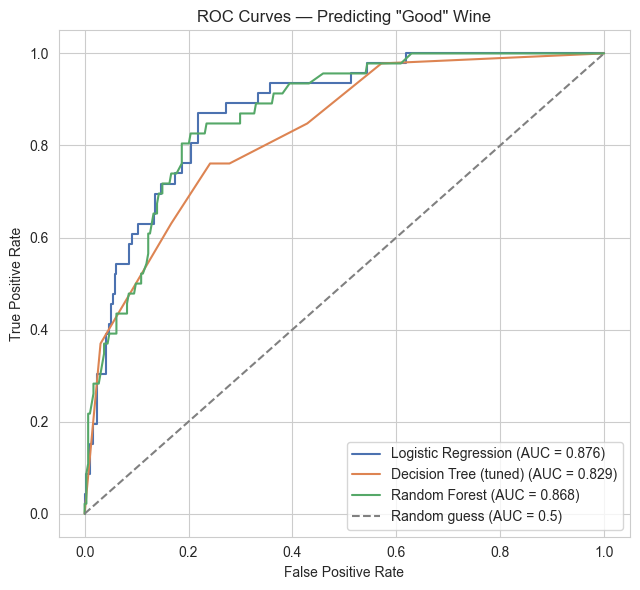

In [7]:
plt.figure(figsize=(6.5, 6))
colors = {'Logistic Regression': '#4C72B0', 'Decision Tree (tuned)': '#DD8452', 'Random Forest': '#55A868'}
for name, (fpr, tpr, _) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC = {results[name]["AUC"]:.3f})', color=colors[name])
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Predicting "Good" Wine')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('images/04_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()

**Result:** Logistic Regression reaches **AUC 0.876** — matching the dataset's own claimed benchmark (~0.88) — and edges out both the hyperparameter-tuned decision tree (0.829) and an untuned random forest (0.868). This is a useful reminder: a properly scaled linear model can beat more complex tree-based models on a clean, modestly-sized, well-behaved feature set like this one. The tuned tree lands on a shallow `max_depth=3` — more interpretable, but leaving real signal on the table.

Note the accuracy/AUC split, too: Random Forest has the **highest raw accuracy (87.9%)**, barely above the 86.5% "always predict not-good" baseline, while Logistic Regression's accuracy (77.6%) is *below* baseline because `class_weight='balanced'` deliberately trades overall accuracy for better minority-class (good wine) recall — the right trade-off here, since a model that never flags a good wine is useless for quality control even if its raw accuracy looks fine.

## 6. What actually drives a "good" prediction?

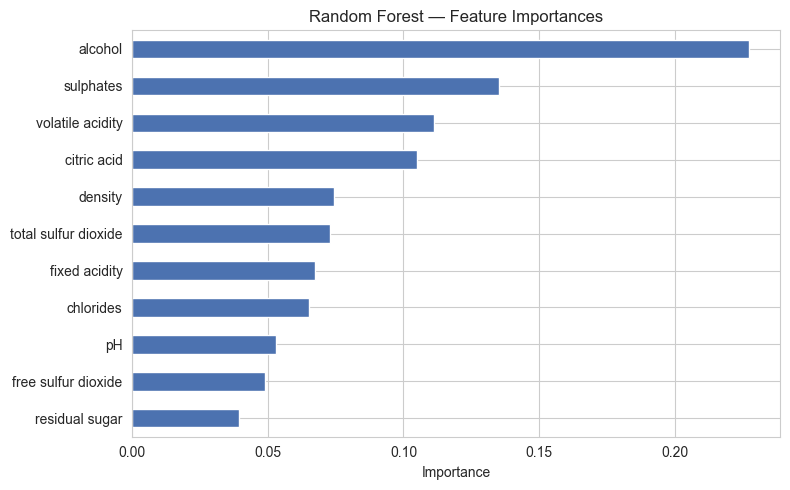

alcohol                 0.227449
sulphates               0.135151
volatile acidity        0.111374
citric acid             0.104832
density                 0.074418
total sulfur dioxide    0.072906
fixed acidity           0.067556
chlorides               0.065123
pH                      0.053009
free sulfur dioxide     0.048991
residual sugar          0.039190
dtype: float64

In [8]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#4C72B0')
plt.title('Random Forest — Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('images/05_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

importances.sort_values(ascending=False)

The Random Forest (which uses all 11 features, unlike the shallow tuned tree) confirms the EDA: **alcohol, sulphates, volatile acidity, and citric acid** are the top four drivers of a "good" rating, together accounting for over half of total feature importance.

## 7. A closer look at the best model's mistakes

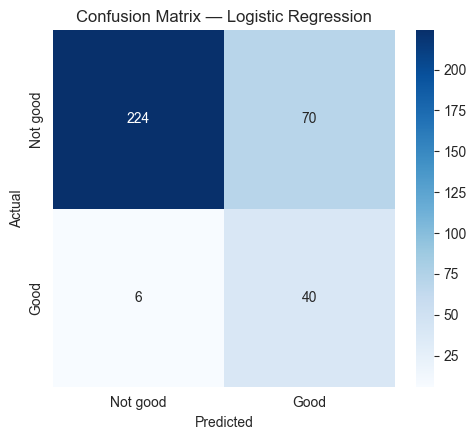

              precision    recall  f1-score   support

    Not good       0.97      0.76      0.85       294
        Good       0.36      0.87      0.51        46

    accuracy                           0.78       340
   macro avg       0.67      0.82      0.68       340
weighted avg       0.89      0.78      0.81       340



In [9]:
threshold = 0.5
y_pred = (proba >= threshold).astype(int)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not good', 'Good'], yticklabels=['Not good', 'Good'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('images/06_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

print(classification_report(y_test, y_pred, target_names=['Not good', 'Good']))

At the default 0.5 threshold, the model catches the large majority of genuinely good wines (high recall on the minority class) at the cost of some false positives — exactly the trade-off `class_weight='balanced'` was set up to make. In a real QC setting, this threshold is a business decision: lowering it catches more good wines (fewer missed) at the cost of more wines flagged for a second look that turn out average.

## 8. Key findings & recommendations

**Findings:**
- Only **13.6%** of wines in this dataset are rated "good" (quality ≥ 7) — a genuinely imbalanced target, so AUC/recall are more informative than raw accuracy here.
- **Alcohol content (+0.48 correlation) and volatile acidity (-0.39) are the two strongest chemical predictors of quality**, followed by sulphates (+0.25) and citric acid (+0.23). Good wines average visibly higher alcohol/sulphates/citric acid and lower volatile acidity, though the distributions overlap enough that no single feature is a reliable cutoff on its own.
- A **properly scaled Logistic Regression (AUC 0.876) matches the dataset's own published benchmark (~0.88) and beats both a hyperparameter-tuned Decision Tree (AUC 0.829) and an untuned Random Forest (AUC 0.868)** — a clean reminder that simpler linear models can outperform tree ensembles on well-behaved, modestly-sized tabular data.
- **240 of 1,599 rows (15%) are exact duplicates** — de-duplicated before modeling to avoid the same wine leaking across the train/test split, a step easy to miss and one that would otherwise inflate reported performance.
- Random Forest feature importances confirm the EDA: **alcohol, sulphates, volatile acidity, and citric acid together account for over half of predictive signal.**

**Recommendations:**
1. For a real QC screening tool, deploy the **Logistic Regression model** — it's both the most accurate by AUC and the most interpretable (coefficients directly show each feature's direction and relative size of effect), unlike the black-box Random Forest.
2. Prioritize **alcohol content and volatile acidity control** in production — they are the two levers most associated with the "good" quality tier, consistent with wine-chemistry theory (volatile acidity is an acetic-acid/vinegar off-flavor).
3. Treat the classification **threshold as a tunable business decision**, not a fixed 0.5 — a QC team that wants to catch nearly every good batch (accepting more false alarms) should lower it; one optimizing inspector time should raise it.
4. Always **de-duplicate before any train/test split** on this dataset (or similar lab-measurement data) — skipping this step silently overstates model performance by letting identical wines appear on both sides of the split.

Full code and outputs are in this notebook.